# E01 — numerical verification of quotient geometry


With \(\Delta\rho=\rho(y)-\rho(d)\), the frozen pullback objective used in the numerical checks is
\[
Q(y,d)=\frac12\,\Delta\rho^{\mathsf T} B_d^{\dagger}\Delta\rho.
\]
E01 verifies positive-scale invariance, the radial null mode, directional response, the local quadratic expansion, conditioning, local Gauss–Newton behavior, and noise consistency. The Gauss–Newton iterations are printed one by one.

In [9]:
from IPython.display import display, Image
import os
import sys
import subprocess
from pathlib import Path

# ============================================================
# Locate the qvvw2 repository
# ============================================================

ROOT = Path.cwd().resolve()

for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "pyproject.toml").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError(
        "Could not locate the qvvw2 repository root."
    )

os.chdir(ROOT)

# ============================================================
# Make sure the current repository is installed
# ============================================================

def current_qvvw2_path():
    try:
        import qvvw2
        return Path(qvvw2.__file__).resolve()
    except ImportError:
        return None


installed_path = current_qvvw2_path()

need_install = (
    installed_path is None
    or ROOT not in installed_path.parents
)

if need_install:
    print("Preparing local qvvw2 package...")

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-e",
            str(ROOT),
            "--no-deps",
            "--no-build-isolation",
            "--quiet",
        ],
        check=True,
    )

# Make the current checkout take priority.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import qvvw2

# ============================================================
# Environment used by experiment subprocesses
# ============================================================

existing_pythonpath = os.environ.get(
    "PYTHONPATH",
    ""
)

pythonpath_parts = [
    str(ROOT)
]

if existing_pythonpath:
    pythonpath_parts.append(
        existing_pythonpath
    )

os.environ["PYTHONPATH"] = os.pathsep.join(
    pythonpath_parts
)

print("Repository :", ROOT)
print("Python     :", sys.executable)
print("qvvw2      :", Path(qvvw2.__file__).resolve())


# ============================================================
# Helper for running experiment scripts
# ============================================================

def run_py(relative_path, *args):
    script = ROOT / relative_path

    if not script.exists():
        raise FileNotFoundError(
            f"Experiment script not found: {script}"
        )

    cmd = [
        sys.executable,
        "-u",
        str(script),
        *map(str, args),
    ]

    env = dict(os.environ)

    print(
        "\n" + "=" * 88,
        flush=True,
    )
    print(
        "RUN:",
        " ".join(cmd),
        flush=True,
    )
    print(
        "=" * 88,
        flush=True,
    )

    subprocess.run(
        cmd,
        cwd=ROOT,
        env=env,
        check=True,
    )


def reset_experiment(exp_id):
    """
    Remove only previously generated results and figures for the
    selected experiment before a fresh rerun.

    Source code, notebooks, inputs, and all other experiments are
    untouched.
    """
    import shutil

    exp = ROOT / "experiments" / exp_id

    for name in ("results", "figures"):
        path = exp / name

        if path.exists():
            shutil.rmtree(path)

    print(
        f"[{exp_id}] previous generated results/figures cleared.",
        flush=True,
    )



Repository : /root/autodl-tmp/qvvw2
Python     : /root/miniconda3/envs/qvvw2/bin/python
qvvw2      : /root/autodl-tmp/qvvw2/qvvw2/__init__.py


In [10]:
reset_experiment("E01")

[E01] previous generated results/figures cleared.


In [11]:
run_py("experiments/E01/code/run_e01.py")


RUN: /root/miniconda3/envs/qvvw2/bin/python -u /root/autodl-tmp/qvvw2/experiments/E01/code/run_e01.py
[E01] Starting numerical verification of quotient geometry
[E01][GN] iter 01/08  error=1.655295e-01  next=1.395164e-02
[E01][GN] iter 02/08  error=1.395164e-02  next=3.462027e-05
[E01][GN] iter 03/08  error=3.462027e-05  next=2.554677e-10
[E01][GN] iter 04/08  error=2.554677e-10  next=1.400694e-16
[E01][GN] iter 05/08  error=1.400694e-16  next=8.923189e-17
[E01][GN] iter 06/08  error=8.923189e-17  next=6.541145e-17
[E01][GN] iter 07/08  error=6.541145e-17  next=5.235781e-17
[E01][GN] iter 08/08  error=5.235781e-17  next=5.273067e-17
[E01] Evaluating noise-consistency grid
[E01][noise] datum_scale=0.65, sigma=0.03
[E01][noise] datum_scale=0.65, sigma=0.05
[E01][noise] datum_scale=0.65, sigma=0.08
[E01][noise] datum_scale=0.85, sigma=0.03
[E01][noise] datum_scale=0.85, sigma=0.05
[E01][noise] datum_scale=0.85, sigma=0.08
[E01][noise] datum_scale=1.10, sigma=0.03
[E01][noise] datum_scale

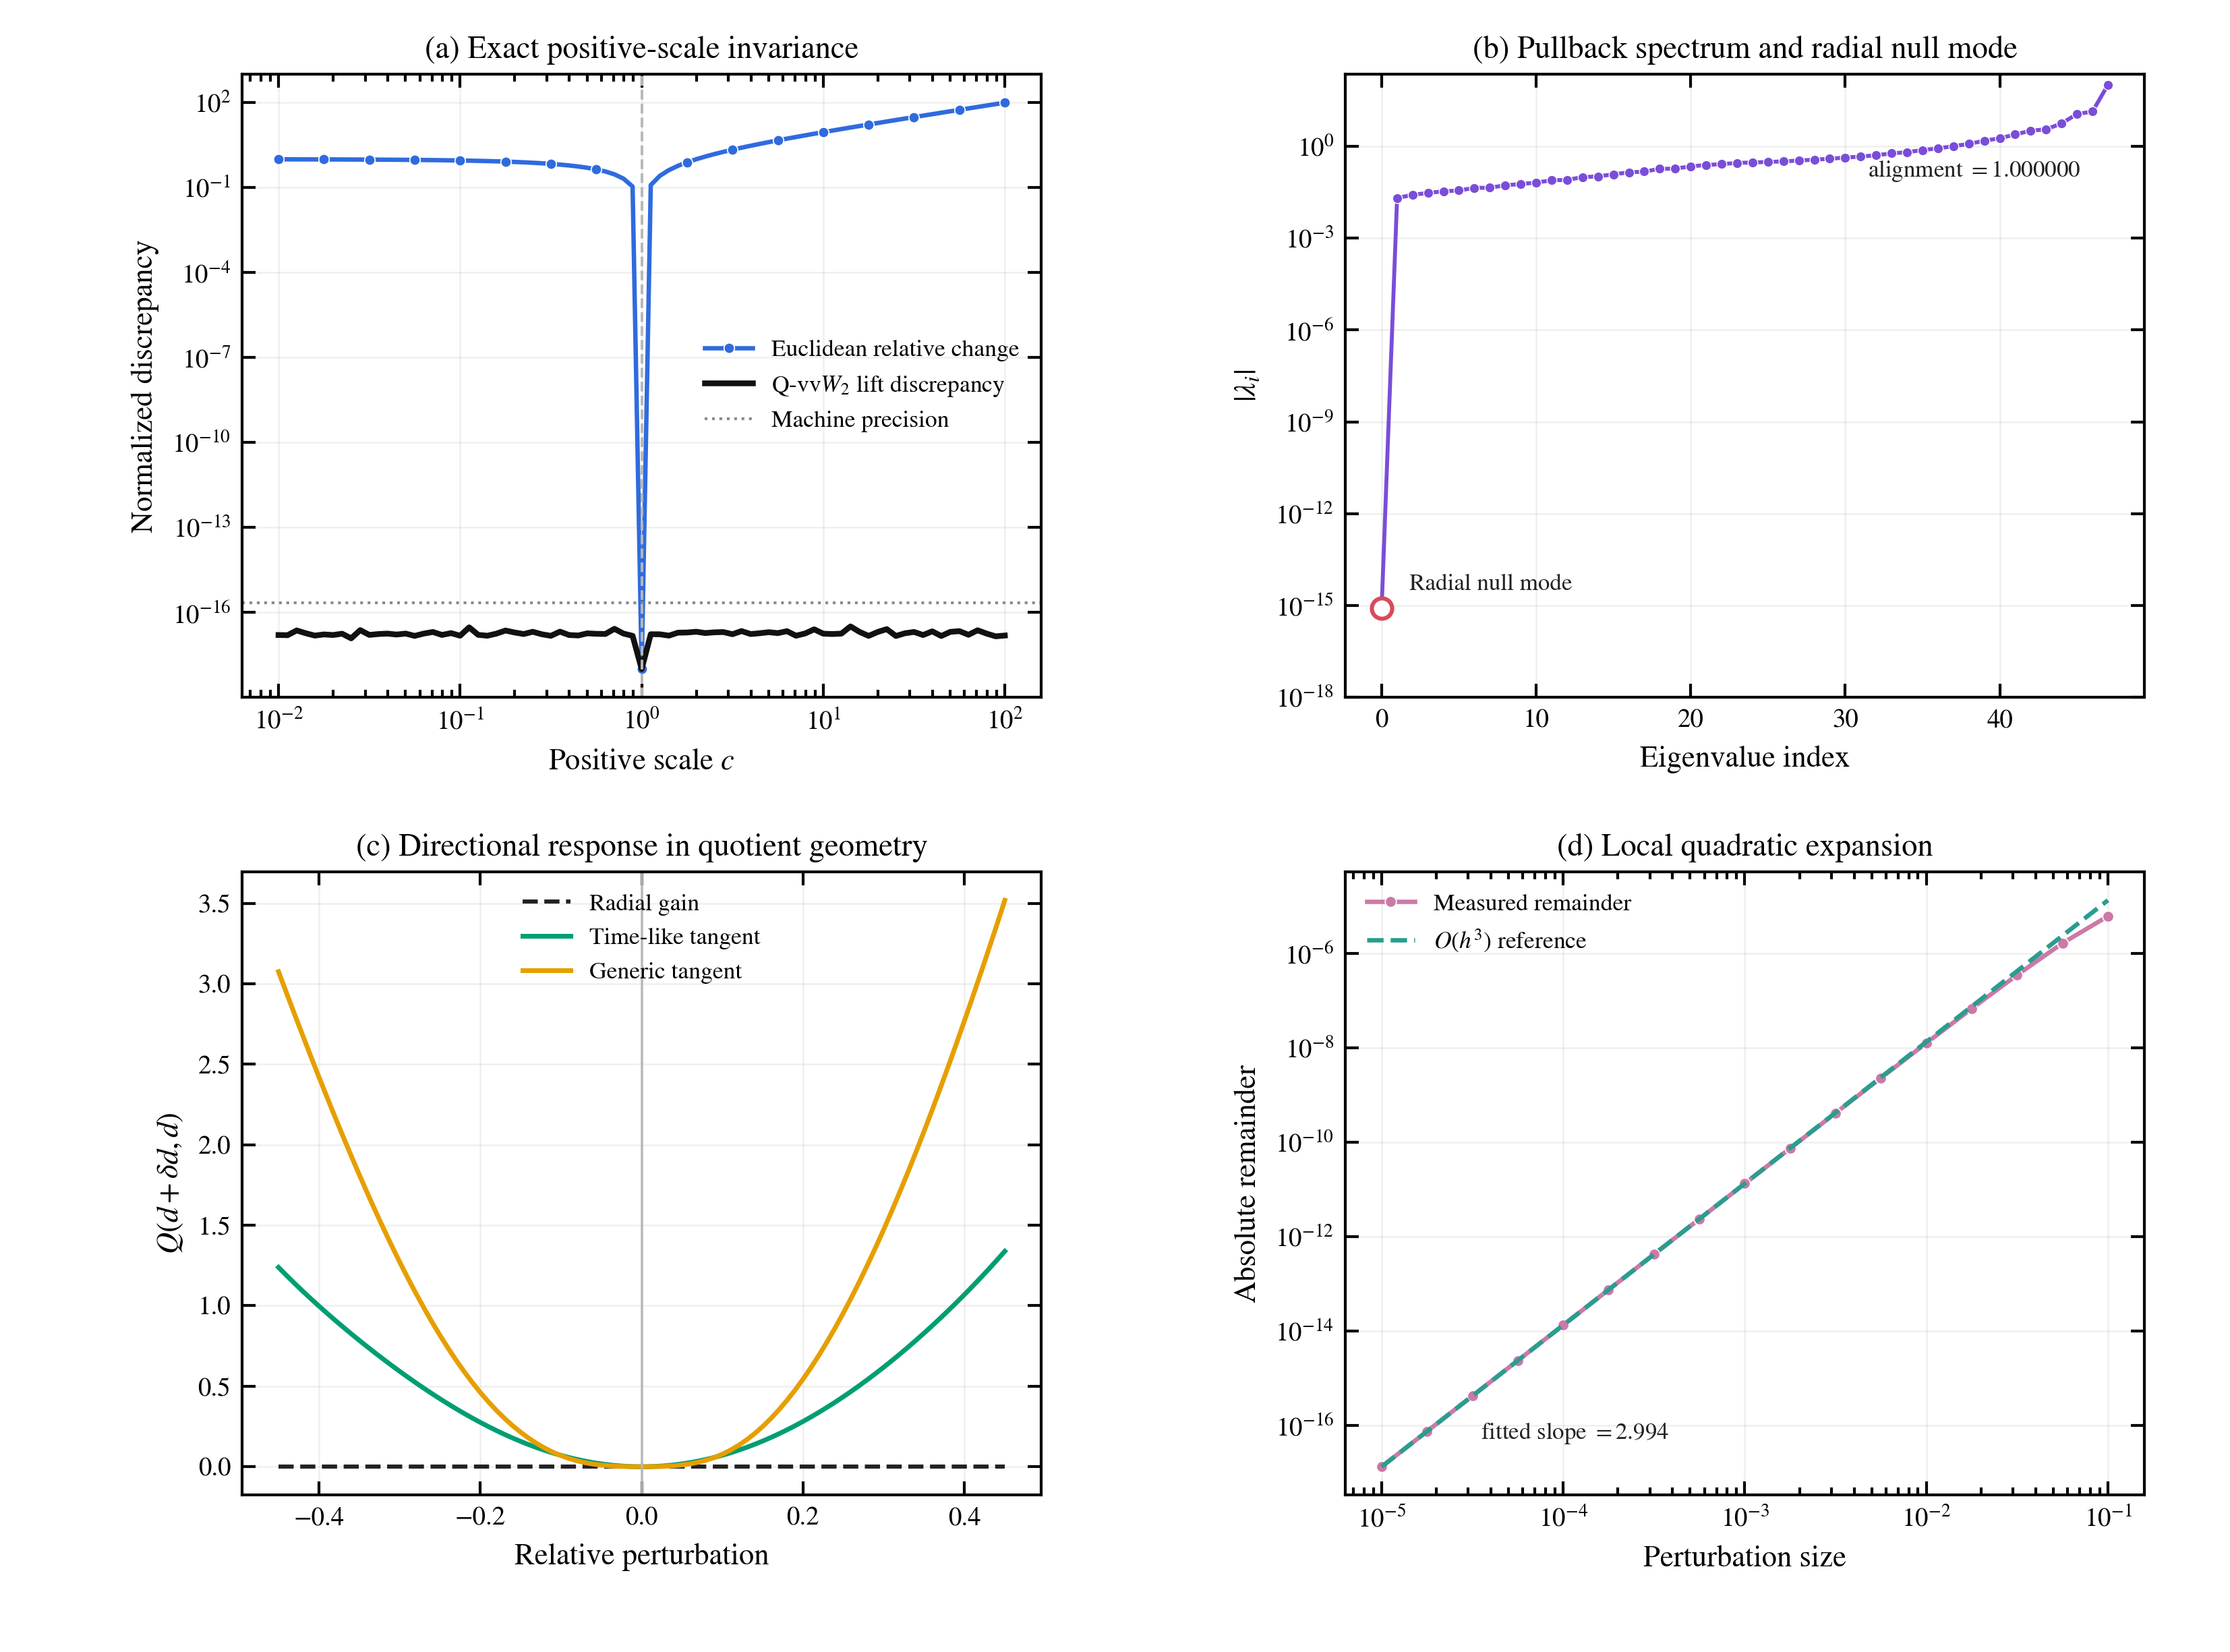

In [12]:
def show_png(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    display(Image(filename=str(path)))

show_png(ROOT / "experiments/E01/figures/Fig02_theory_verification.png")